# Task 2: Time Series Forecasting Models for TSLA

**Objective:** Build, train, and compare ARIMA and LSTM models to forecast
Tesla's future closing price, evaluating trade-offs between simplicity and performance.

**Approach:**
1. Chronological train/test split (train: 2015–2024, test: 2025–2026)
2. ARIMA/SARIMA — classical statistical forecasting
3. LSTM — deep learning sequence model
4. Compare using MAE, RMSE, MAPE

## 1. Setup and Imports

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.data_loader import fetch_stock_data, extract_close_prices, clean_data
from src.train_test_split import chronological_split
from src.models.arima_model import (
    find_best_arima_order, fit_arima, forecast_arima, plot_arima_forecast
)
from src.models.lstm_model import (
    scale_data, create_sequences, build_lstm_model,
    train_lstm, forecast_lstm, plot_training_history
)
from src.evaluation import calculate_metrics, compare_models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)

print("All imports successful!")

All imports successful!


## 2.Loading Tesla Data

[*********************100%***********************]  1 of 1 completed


[INFO] Downloaded data shape: (2888, 5)
[INFO] Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
[INFO] Missing values — before: 0, after: 0


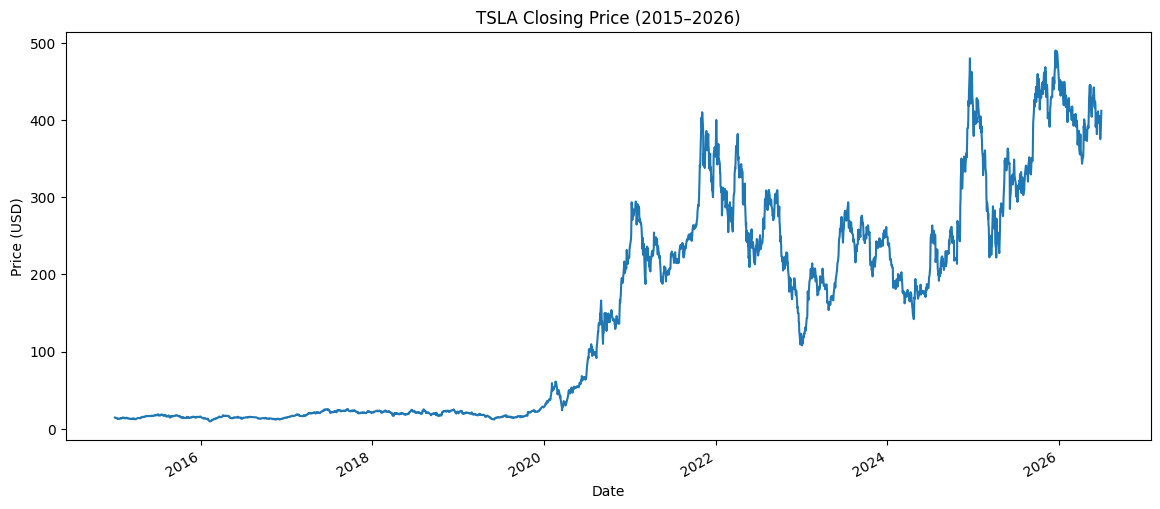

In [3]:
tickers = ["TSLA"]
start_date = "2015-01-01"
end_date = "2026-06-30"

raw_data = fetch_stock_data(tickers, start_date, end_date)
close_prices = extract_close_prices(raw_data, tickers)
close_prices_clean = clean_data(close_prices)

tsla = close_prices_clean["TSLA"]
tsla.plot(title="TSLA Closing Price (2015–2026)")
plt.ylabel("Price (USD)")
plt.show()

## 3.Chronological Train/Test Split

[INFO] Train period: 2015-01-02 00:00:00 → 2024-12-31 00:00:00
[INFO] Train size:   2516 days
[INFO] Test period:  2025-01-02 00:00:00 → 2026-06-29 00:00:00
[INFO] Test size:    372 days


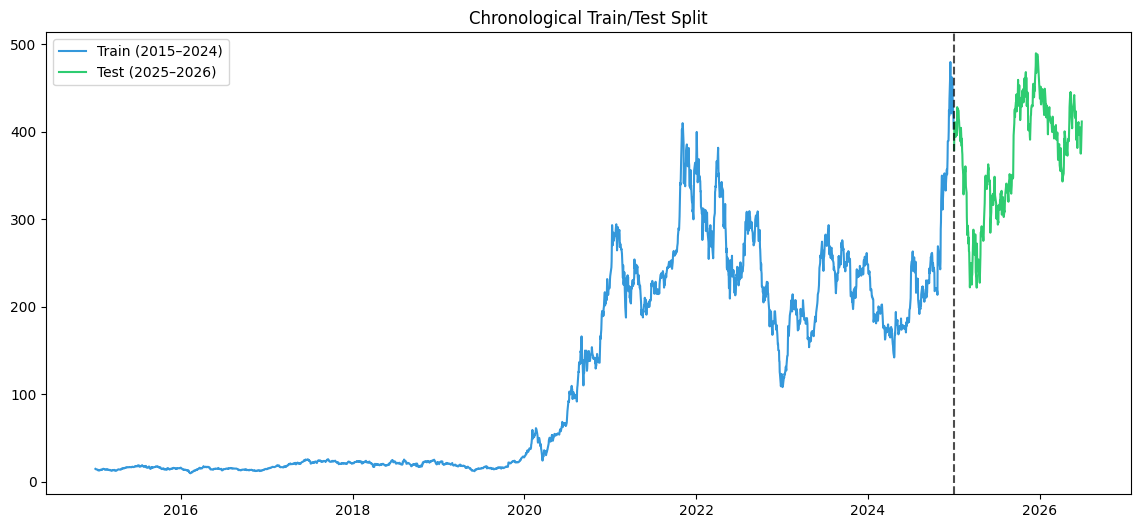

In [4]:
train, test = chronological_split(tsla, split_date="2025-01-01")

plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train (2015–2024)", color="#3498db")
plt.plot(test.index, test, label="Test (2025–2026)", color="#2ecc71")
plt.axvline(x=train.index[-1], color="black", linestyle="--", alpha=0.7)
plt.title("Chronological Train/Test Split")
plt.legend()
plt.show()

## 4. ARIMA/SARIMA Model
### 4.1 Confirm Stationarity

ADF p-value on TSLA price (train): 0.8751
=> Non-stationary, as expected. auto_arima will handle differencing (d).


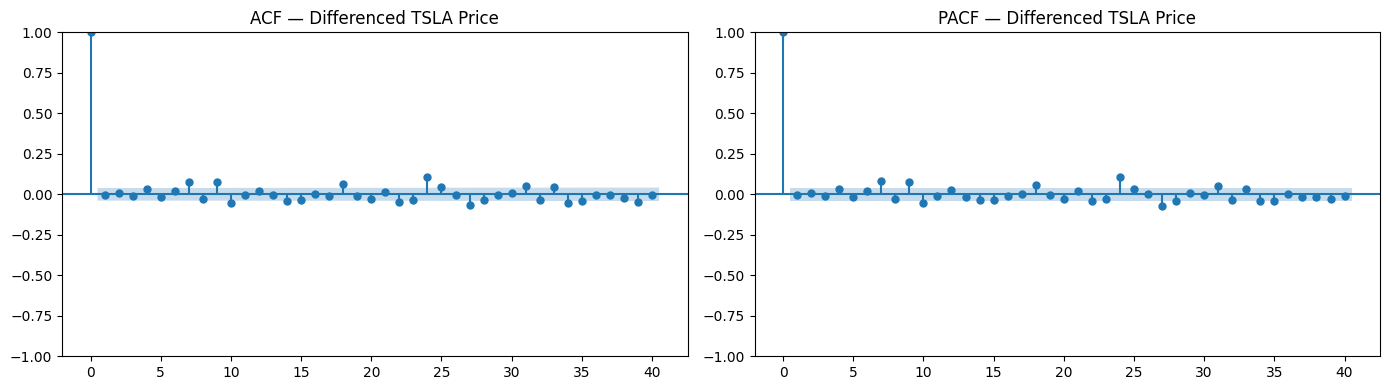

In [5]:
result = adfuller(train.dropna())
print(f"ADF p-value on TSLA price (train): {result[1]:.4f}")
print("=> Non-stationary, as expected. auto_arima will handle differencing (d).")

train_diff = train.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_diff, ax=axes[0], lags=40)
plot_pacf(train_diff, ax=axes[1], lags=40)
axes[0].set_title("ACF — Differenced TSLA Price")
axes[1].set_title("PACF — Differenced TSLA Price")
plt.tight_layout()
plt.show()

### 4.2 Find Best Parameters and Fit

In [6]:
arima_model = find_best_arima_order(train, seasonal=False)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.50 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.84 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=1.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.32 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=1.22 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 4.056 seconds

[INFO] Best order found: (0, 1, 0)
[INFO] AIC: 16368.11


### 4.3 Forecast and Visualize

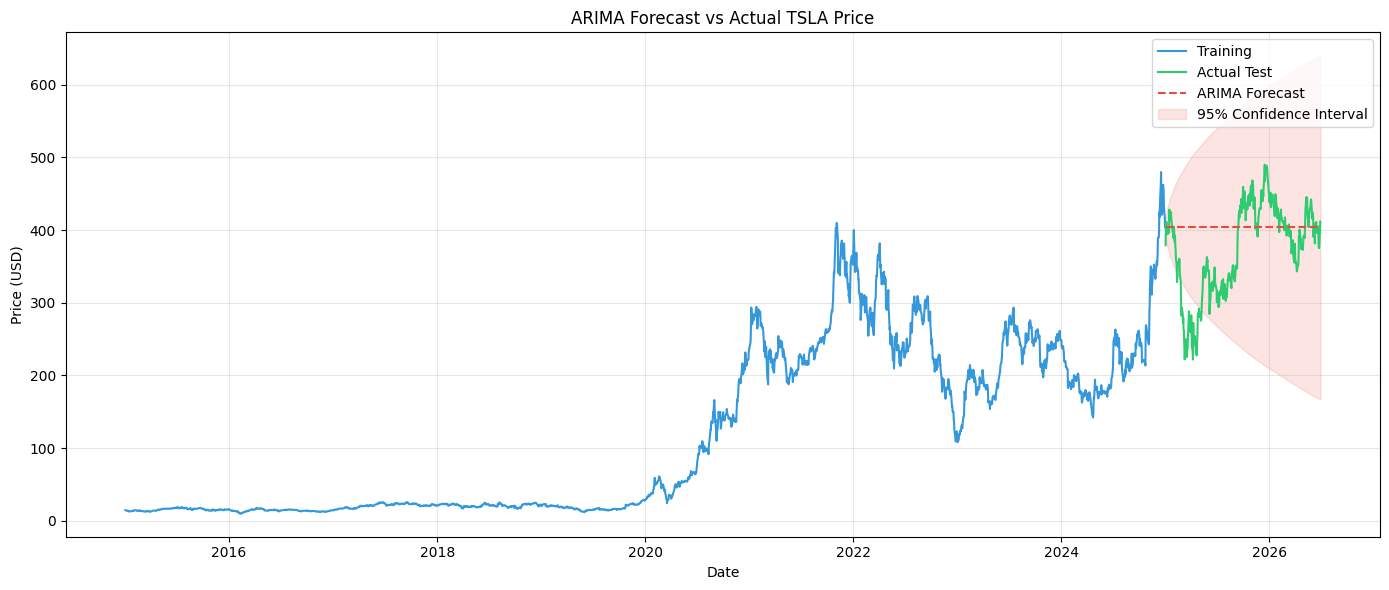

In [7]:
arima_forecast, arima_conf_int = forecast_arima(arima_model, steps=len(test), is_pmdarima=True)

plot_arima_forecast(train, test, arima_forecast, arima_conf_int,
                     title="ARIMA Forecast vs Actual TSLA Price")

## 5. LSTM Model
### 5.1 Scale Data and Create Sequences

In [8]:
window_size = 60

train_scaled, test_scaled, scaler = scale_data(train, test)
X_train, y_train = create_sequences(train_scaled, window_size=window_size)

print(f"X_train shape: {X_train.shape}")  # (samples, 60, 1)
print(f"y_train shape: {y_train.shape}")

X_train shape: (2456, 60, 1)
y_train shape: (2456,)


### 5.2 Build and Train the Model

In [9]:
lstm_model = build_lstm_model(window_size=window_size, units=50, dropout_rate=0.2)

In [10]:
history = train_lstm(lstm_model, X_train, y_train, epochs=25, batch_size=32)

Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - loss: 0.0182 - val_loss: 0.0045
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0019 - val_loss: 0.0038
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0019 - val_loss: 0.0039
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0015 - val_loss: 0.0033
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - loss: 0.0011 - val_loss: 0.0031
Epoch 6/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - loss: 0.0012 - val_loss: 0.0040
Epoch 7/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - loss: 0.0011 - val_loss: 0.0024
Epoch 8/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - loss: 9.7127e-04 - val_loss: 0.0063
Epoch 9/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0015 - val_loss: 0.0046
Epoch 10/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 11/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 8.9105e-04 - val_loss: 0.0043
Epoch 12/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/ste

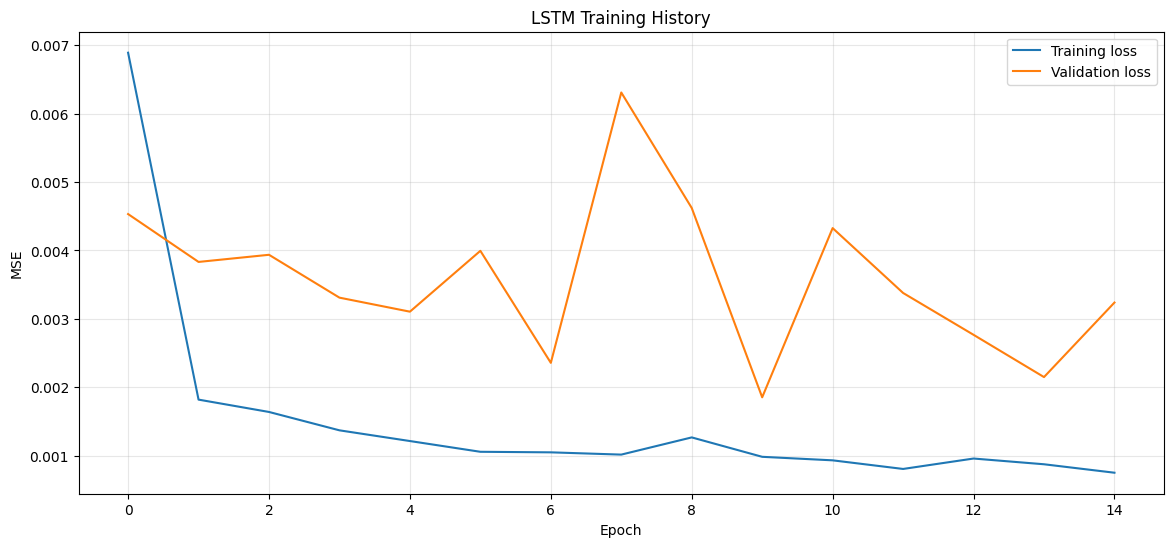

In [11]:
plot_training_history(history)

### 5.3 Forecast and Visualize

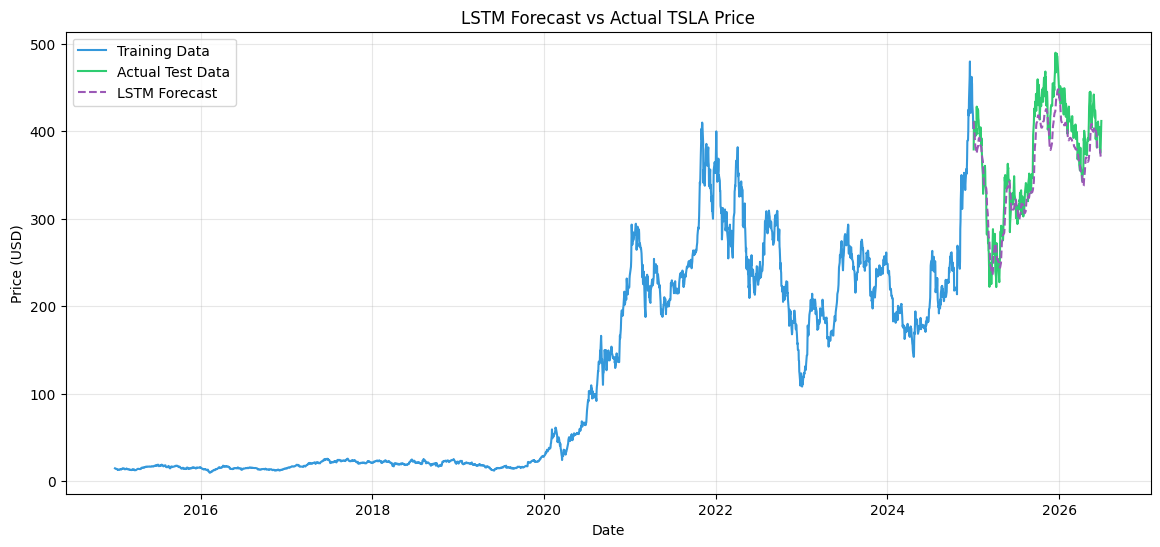

In [12]:
lstm_forecast = forecast_lstm(lstm_model, train_scaled, test_scaled, window_size, scaler)

plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Training Data", color="#3498db")
plt.plot(test.index, test, label="Actual Test Data", color="#2ecc71")
plt.plot(test.index, lstm_forecast, label="LSTM Forecast", color="#9b59b6", linestyle="--")
plt.title("LSTM Forecast vs Actual TSLA Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Model Comparison

In [13]:
arima_metrics = calculate_metrics(test.values, arima_forecast, model_name="ARIMA")
lstm_metrics = calculate_metrics(test.values, lstm_forecast, model_name="LSTM")

comparison_table = compare_models([arima_metrics, lstm_metrics])
comparison_table

ARIMA performance:
  MAE  : 54.4412
  RMSE : 70.5393
  MAPE : 17.24%

LSTM performance:
  MAE  : 21.1221
  RMSE : 26.0830
  MAPE : 5.59%



,Model,MAE,RMSE,MAPE (%)
0,LSTM,21.1221,26.0830,5.59
1,ARIMA,54.4412,70.5393,17.24


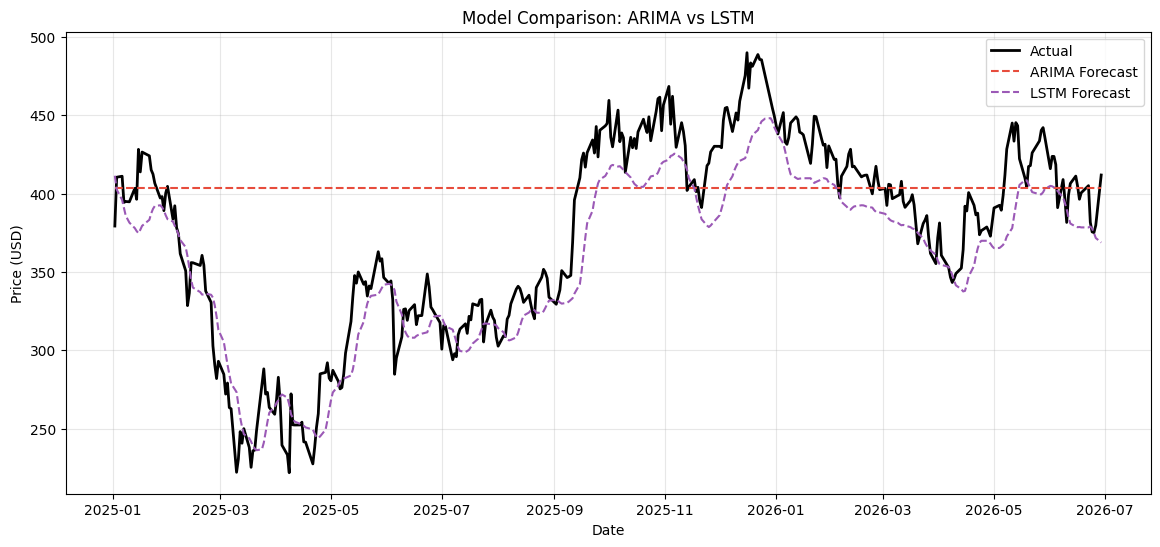

In [14]:
plt.figure(figsize=(14,6))
plt.plot(test.index, test, label="Actual", color="black", linewidth=2)
plt.plot(test.index, arima_forecast, label="ARIMA Forecast", color="#e74c3c", linestyle="--")
plt.plot(test.index, lstm_forecast, label="LSTM Forecast", color="#9b59b6", linestyle="--")
plt.title("Model Comparison: ARIMA vs LSTM")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Discussion and Model Selection Rationale

### Results Summary
| Model | MAE | RMSE | MAPE (%) |
|-------|-----|------|----------|
| ARIMA | 54.4412 | 70.5393  | 17.24      |
| LSTM  | 21.1221 | 26.0830  | 5.59      |

### Discussion
- **Which model performed better, and by how much?**
  The **LSTM** model performed significantly better than the ARIMA model across all evaluated metrics:
  - **MAE** was reduced by **33.32 points** (from 54.4412 to 21.1221, a ~61.2% improvement).
  - **RMSE** was reduced by **44.46 points** (from 70.5393 to 26.0830, a ~63.0% improvement).
  - **MAPE** was reduced by **11.65%** (from 17.24% to 5.59%, a ~67.6% improvement).

- **Why might that be the case?**
  - **ARIMA** was optimized to an order of `(0, 1, 0)` (equivalent to a random walk). Because ARIMA is a linear model that requires stationarity, its out-of-sample forecast quickly reverts to a flat mean line projection, making it unable to trace TSLA's volatile price fluctuations over the 372-day test set.
  - **LSTM** leverages its memory cells and hidden states to process the sequence of 60 trading days (lookback window). This allows the neural network to capture the complex, non-linear dynamics, trends, and momentum of the stock price, keeping its forecasts close to the actual price path.

- **Trade-offs:**
  - **ARIMA**: Extremely fast to train (takes ~4 seconds to fit and select order via `pmdarima`), has highly interpretable parameters, and provides clear probabilistic confidence intervals. However, it fails on non-linear data and long-term predictions.
  - **LSTM**: Much slower and computationally intensive (requires training a deep neural network over 25 epochs), highly sensitive to hyperparameter tuning, and works as a "black box" with no native statistical confidence intervals.

- **Recommendation:**
  For GMF's portfolio decisions, we recommend a **hybrid framework or LSTM forecasts with statistical risk boundaries**:
  - **Use LSTM as the core forecasting engine** for active asset allocation and directional trades, given its superior accuracy and low percentage error (5.59% MAPE).
  - **Use risk-overlay models** (such as standard deviation, Value at Risk from `src/risk_metrics.py`, and ARIMA's statistical boundaries) as risk management controls. This ensures that the portfolio manager has explainable limits and stop-losses to protect capital in the event of an LSTM prediction anomaly or market regime shift.
